# 04 — Error Analysis: LightGBM, Random Forest, XGBoost

`03_model_extension.ipynb` found LightGBM the clear leader (PR-AUC 0.245), with Random Forest and
XGBoost tied a step behind (0.229 each). Aggregate metrics can't say *where* each model succeeds
or fails, or whether the two runners-up are making the same mistakes as the leader or genuinely
different ones -- which is exactly what decides whether an ensemble is worth trying later. This
notebook does that: segment-level performance, confusion-matrix error types, cross-model error
overlap, feature-importance comparison, and a qualitative look at specific missed/caught clients.

Per the sequencing agreed with the team, this happens **before** any hyperparameter tuning --
it's cheap (reuses the same out-of-fold predictions as `03`, no new modelling ideas needed to
start), and its findings should decide what gets tuned and whether ensembling is worth trying,
rather than tuning blind.

## Imports and constants

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
TRAIN_FEATURES_PATH = PROCESSED_DIR / "train_client_features.csv"

RSEED = 42  # same seed 01_eda.ipynb / 02_baseline_model.ipynb / 03_model_extension.ipynb use
N_SPLITS = 5
TOP_K_SHARE = 0.10  # same capacity slice as 02 and 03, so "flagged" means the same thing here

if not TRAIN_FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Missing {TRAIN_FEATURES_PATH}. Run 01_eda.ipynb with SAVE_CSV_FILE=true first "
        "to produce the cleaned, client-level feature table this notebook loads."
    )

## Step 1 — Load the cleaned, client-level features

In [36]:
df = pd.read_csv(TRAIN_FEATURES_PATH)
df["client_id"] = df["client_id"].astype("string")
df["target"] = df["target"].astype("int8")

expected_columns = {
    "client_id", "target",
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
    "client_catg", "disrict", "region",
}
missing_columns = sorted(expected_columns - set(df.columns))
if missing_columns:
    raise ValueError(f"{TRAIN_FEATURES_PATH} is missing required baseline columns: {missing_columns}")

overview = pd.DataFrame({
    "rows": [len(df)], "unique_clients": [df["client_id"].nunique()], "fraud_rate": [df["target"].mean()],
})
display(overview)

,rows,unique_clients,fraud_rate
0,108394,108394,0.055843


## Step 2 — Preprocessing (identical to `02`/`03`)

This notebook uses the same finalized 15-input contract as the baseline and model extension: 12 numeric features plus the categorical codes `client_catg`, `disrict`, and `region`. Raw dates, tenure, identifiers, and investigation-related fields are not model inputs. Numeric values are median-imputed and scaled; categories are one-hot encoded inside the cross-validation pipeline.

In [37]:
categorical_features = ["client_catg", "region", "disrict"]
numeric_features = [
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
]

model_features = numeric_features + categorical_features
X = df[model_features]
y = df["target"]
y_values = y.to_numpy()

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RSEED)

## Step 3 — Recompute out-of-fold predictions for the three tree ensembles

Same model configurations as `03_model_extension.ipynb` (same `class_weight`/`scale_pos_weight`,
same seed, same CV) -- duplicated rather than imported so this notebook runs on its own. Only
the three tree ensembles are needed here; logistic regression, KNN, and Isolation Forest already
have their story from `03` and aren't the subject of this analysis.

In [38]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

model_specs = {
    "lightgbm": LGBMClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1, verbosity=-1),
    "random_forest": RandomForestClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1),
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RSEED, n_jobs=-1
    ),
}

oof_probas = {}
for name, model in model_specs.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    oof_probas[name] = cross_val_predict(pipeline, X, y, cv=cv, method="predict_proba")[:, 1]
    print(f"done: {name}")

done: lightgbm
done: random_forest
done: xgboost


## Step 4 — Confusion matrix at the top-10% cutoff

Each model gets its own threshold (the score at its own 90th percentile) -- the same
capacity-aware framing as `02`/`03`, since the three models' raw scores aren't on comparable
scales.

In [39]:
k = int(np.ceil(TOP_K_SHARE * len(y_values)))

flags = {}
confusion_rows = {}
for name, proba in oof_probas.items():
    threshold = np.sort(proba)[::-1][k - 1]
    flagged = proba >= threshold
    flags[name] = flagged

    true_positive = int((flagged & (y_values == 1)).sum())
    false_positive = int((flagged & (y_values == 0)).sum())
    false_negative = int((~flagged & (y_values == 1)).sum())
    true_negative = int((~flagged & (y_values == 0)).sum())
    confusion_rows[name] = {
        "true_positive": true_positive, "false_positive": false_positive,
        "false_negative": false_negative, "true_negative": true_negative,
        "precision_at_k": true_positive / (true_positive + false_positive),
        "recall_at_k": true_positive / (true_positive + false_negative),
    }

confusion_summary = pd.DataFrame(confusion_rows).T
display(confusion_summary)

,true_positive,false_positive,false_negative,true_negative,precision_at_k,recall_at_k
lightgbm,2611.0,8229.0,3442.0,94112.0,0.240867,0.431356
random_forest,2622.0,8713.0,3431.0,93628.0,0.231319,0.433174
xgboost,2523.0,8317.0,3530.0,94024.0,0.232749,0.416818


## Step 5 — Segment-level performance

Recall and precision computed *within* each segment, using the same top-10% flags from Step 4 --
this is where a strong overall score can hide a weak or unfair segment (README guardrail #7).
The invoice-count quintiles are the same bins the EDA used for the observation-window-bias
finding, now asking the model-relevant version of that question: does the model *also* catch
less fraud among short-history clients, not just "is the label rarer there." 

Recall/precision by client_catg:


,segment,clients,fraud_cases,lightgbm_recall,lightgbm_precision,random_forest_recall,random_forest_precision,xgboost_recall,xgboost_precision
0,11,105216,5758,0.424800,0.238588,0.426711,0.229134,0.417506,0.230489
2,51,1299,220,0.686364,0.314583,0.700000,0.303150,0.500000,0.325444
1,12,1879,75,0.186667,0.129630,0.146667,0.105769,0.120000,0.125000


Recall/precision by disrict:


,segment,clients,fraud_cases,lightgbm_recall,lightgbm_precision,random_forest_recall,random_forest_precision,xgboost_recall,xgboost_precision
3,69,27391,1943,0.338137,0.211935,0.365414,0.199887,0.346886,0.191586
1,62,32336,1682,0.424495,0.236502,0.424495,0.221464,0.399524,0.235955
2,63,23207,1506,0.565737,0.309144,0.575033,0.300590,0.537849,0.300892
0,60,25460,922,0.420824,0.197455,0.360087,0.197855,0.398048,0.205948


Recall/precision by region (top 15 by fraud case count):


,segment,clients,fraud_cases,lightgbm_recall,lightgbm_precision,random_forest_recall,random_forest_precision,xgboost_recall,xgboost_precision
0,101,26938,977,0.417605,0.198637,0.358240,0.198300,0.399181,0.207226
16,311,9966,800,0.693750,0.352157,0.673750,0.350911,0.641250,0.350649
1,103,7144,734,0.501362,0.229283,0.505450,0.222689,0.505450,0.207843
2,104,10319,569,0.231986,0.203390,0.256591,0.171362,0.235501,0.170483
5,107,7990,524,0.250000,0.192647,0.312977,0.193625,0.282443,0.187579
8,303,4821,265,0.449057,0.231068,0.422642,0.222664,0.422642,0.235789
6,301,7646,249,0.248996,0.197452,0.345382,0.195900,0.285141,0.179747
11,306,4841,225,0.333333,0.237342,0.435556,0.235012,0.400000,0.235602
9,304,3056,215,0.404651,0.224806,0.409302,0.214112,0.441860,0.238095
7,302,3458,214,0.500000,0.250585,0.467290,0.235294,0.462617,0.255814


Recall/precision by invoice-count quintile:


,segment,clients,fraud_cases,lightgbm_recall,lightgbm_precision,random_forest_recall,random_forest_precision,xgboost_recall,xgboost_precision
4,"(57.0, 380.0]",21448,1933,0.518883,0.250374,0.531816,0.252332,0.486808,0.257808
3,"(36.0, 57.0]",21879,1672,0.467105,0.243682,0.464713,0.233966,0.444378,0.230674
2,"(22.0, 36.0]",21053,1416,0.444915,0.238636,0.438559,0.227556,0.446328,0.225714
1,"(7.0, 22.0]",22301,828,0.235507,0.207006,0.221014,0.182635,0.241546,0.180995
0,"(0.999, 7.0]",21713,204,0.009804,0.042553,0.063725,0.062201,0.034314,0.109375


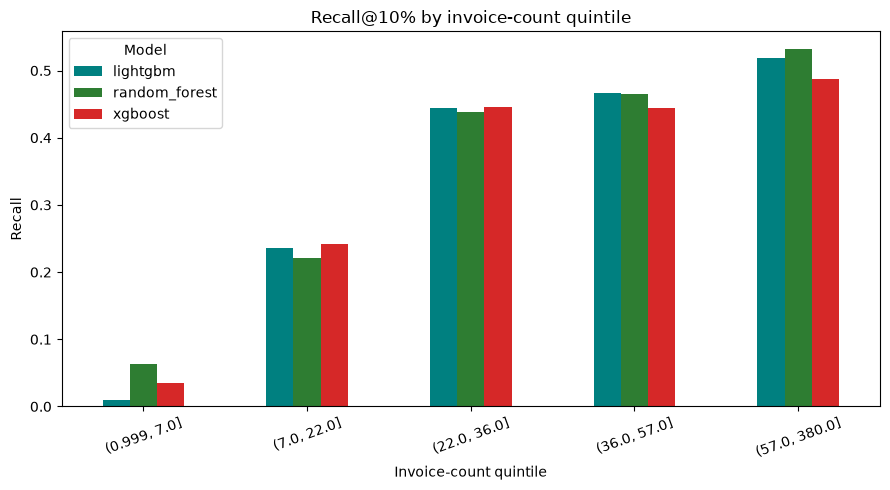

In [40]:
def segment_performance(frame, column, model_names, minimum_clients=50):
    rows = []
    for segment_value, group in frame.groupby(column, dropna=False):
        if len(group) < minimum_clients:
            continue
        fraud_cases = group["target"].sum()
        row = {"segment": segment_value, "clients": len(group), "fraud_cases": fraud_cases}
        for name in model_names:
            flagged = group[f"flagged_{name}"]
            caught = int((flagged & (group["target"] == 1)).sum())
            flagged_count = int(flagged.sum())
            row[f"{name}_recall"] = caught / fraud_cases if fraud_cases > 0 else np.nan
            row[f"{name}_precision"] = caught / flagged_count if flagged_count > 0 else np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values("fraud_cases", ascending=False)


analysis = df.copy()
for name, flagged in flags.items():
    analysis[f"flagged_{name}"] = flagged
analysis["invoice_count_quintile"] = pd.qcut(analysis["invoice_count"], q=5, duplicates="drop")

model_names = list(model_specs.keys())

print("Recall/precision by client_catg:")
display(segment_performance(analysis, "client_catg", model_names))

print("Recall/precision by disrict:")
display(segment_performance(analysis, "disrict", model_names))

print("Recall/precision by region (top 15 by fraud case count):")
display(segment_performance(analysis, "region", model_names).head(15))

print("Recall/precision by invoice-count quintile:")
quintile_table = segment_performance(analysis, "invoice_count_quintile", model_names)
display(quintile_table)

recall_columns = [f"{name}_recall" for name in model_names]
plot_table = quintile_table.sort_values("segment").set_index("segment")[recall_columns]
plot_table.columns = model_names
ax = plot_table.plot(kind="bar", figsize=(9, 5), color=["#008080", "#2E7D32", "#D62828"])
ax.set(title="Recall@10% by invoice-count quintile", xlabel="Invoice-count quintile", ylabel="Recall")
ax.legend(title="Model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Step 6 — Do the three models miss the same fraud, or different fraud?

The question that actually decides whether ensembling is worth trying later: for each fraud
client, count how many of the three models missed them (0 = every model caught them, 3 = every
model missed them). If misses cluster at 0 and 3, the models agree with each other and an
ensemble won't help much. If there's a lot of "missed by exactly 1 or 2," the models are making
different mistakes, and averaging/combining them could genuinely catch more fraud than any one
model alone.

Among all fraud clients, how many of the 3 models missed them:


,fraud_clients
0,1727
1,876
2,823
3,2627



Among all non-fraud clients, how many of the 3 models falsely flagged them:


,non_fraud_clients
0,89166
1,5332
2,3602
3,4241


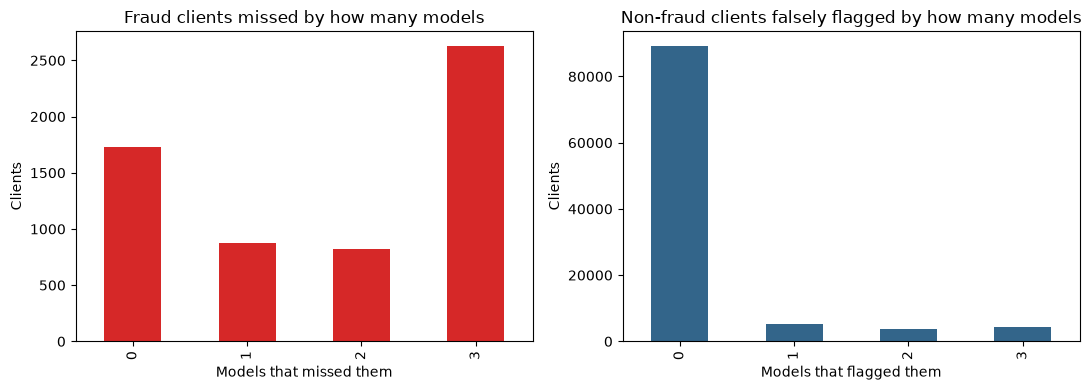

In [41]:
fraud_positions = np.flatnonzero(y_values == 1)
non_fraud_positions = np.flatnonzero(y_values == 0)

missed_by = pd.DataFrame(
    {name: ~flags[name][fraud_positions] for name in model_names}, index=fraud_positions
)
missed_count = missed_by.sum(axis=1)
print("Among all fraud clients, how many of the 3 models missed them:")
display(missed_count.value_counts().sort_index().rename("fraud_clients").to_frame())

falsely_flagged_by = pd.DataFrame(
    {name: flags[name][non_fraud_positions] for name in model_names}, index=non_fraud_positions
)
falsely_flagged_count = falsely_flagged_by.sum(axis=1)
print("\nAmong all non-fraud clients, how many of the 3 models falsely flagged them:")
display(falsely_flagged_count.value_counts().sort_index().rename("non_fraud_clients").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
missed_count.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#D62828")
axes[0].set(title="Fraud clients missed by how many models", xlabel="Models that missed them", ylabel="Clients")
falsely_flagged_count.value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#33658A")
axes[1].set(title="Non-fraud clients falsely flagged by how many models", xlabel="Models that flagged them", ylabel="Clients")
plt.tight_layout()
plt.show()

## Step 7 — Where the models agree and disagree on catching fraud

Step 6 counted *how many* models missed each fraud client; this section shows *which* clients
and *where*. Two views: a client-by-client scatter of each pair of models' scores (colored by
how many models missed that client), and a segment-level breakdown of the same agreement
categories -- then a dedicated close-up on the clients every model misses, since that's the
group we most need to understand.

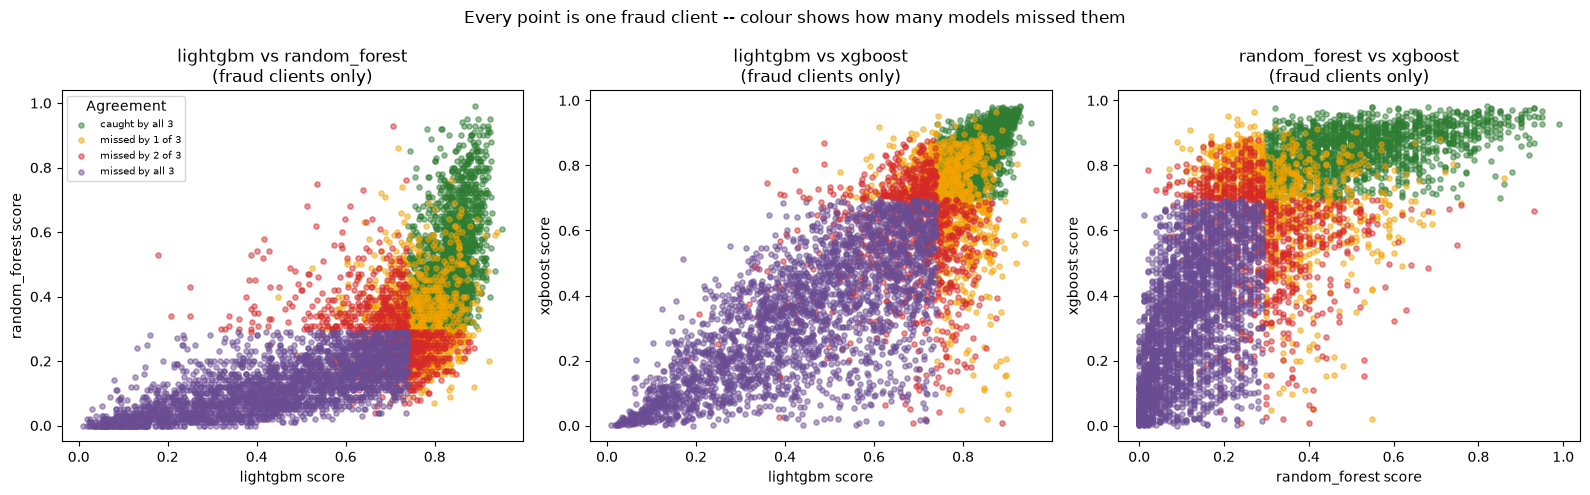

In [42]:
agreement_labels = {
    0: "caught by all 3", 1: "missed by 1 of 3", 2: "missed by 2 of 3", 3: "missed by all 3",
}
fraud_agreement = missed_count.map(agreement_labels)  # index = fraud_positions, from Step 6

palette = {
    "caught by all 3": "#2E7D32", "missed by 1 of 3": "#F4A300",
    "missed by 2 of 3": "#D62828", "missed by all 3": "#6A4C93",
}
agreement_order = list(palette.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [("lightgbm", "random_forest"), ("lightgbm", "xgboost"), ("random_forest", "xgboost")]
for ax, (model_a, model_b) in zip(axes, pairs):
    for label in agreement_order:
        positions = fraud_agreement[fraud_agreement == label].index
        ax.scatter(oof_probas[model_a][positions], oof_probas[model_b][positions],
                   s=14, alpha=0.5, color=palette[label], label=label)
    ax.set(xlabel=f"{model_a} score", ylabel=f"{model_b} score",
           title=f"{model_a} vs {model_b}\n(fraud clients only)")
axes[0].legend(fontsize=7.5, loc="upper left", title="Agreement")
fig.suptitle("Every point is one fraud client -- colour shows how many models missed them")
plt.tight_layout()
plt.show()

### By segment

The same four agreement categories, now broken down by invoice-count quintile and by
`client_catg` -- do the disagreements and unanimous misses concentrate in particular segments,
or are they spread evenly?

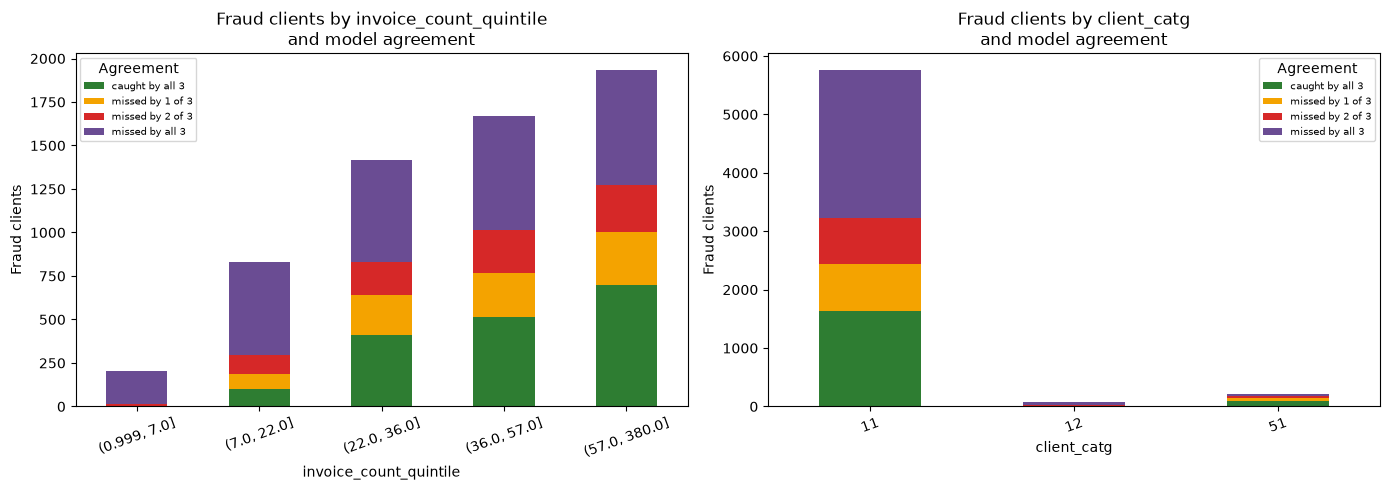

In [43]:
analysis["agreement"] = pd.NA
analysis.loc[fraud_agreement.index, "agreement"] = fraud_agreement.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, column in zip(axes, ["invoice_count_quintile", "client_catg"]):
    counts = (
        analysis.dropna(subset=["agreement"])
        .groupby([column, "agreement"], observed=True).size()
        .unstack("agreement").reindex(columns=agreement_order)
    )
    counts.plot(kind="bar", stacked=True, ax=ax, color=[palette[c] for c in agreement_order])
    ax.set(title=f"Fraud clients by {column}\nand model agreement", ylabel="Fraud clients")
    ax.legend(fontsize=7, title="Agreement")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### A closer look at the fraud clients every model misses

Not mixed in with the other categories this time -- just the "missed by all 3" group on its
own, to see concretely where these clients concentrate.

2627 fraud clients missed by all 3 models -- where do they concentrate?


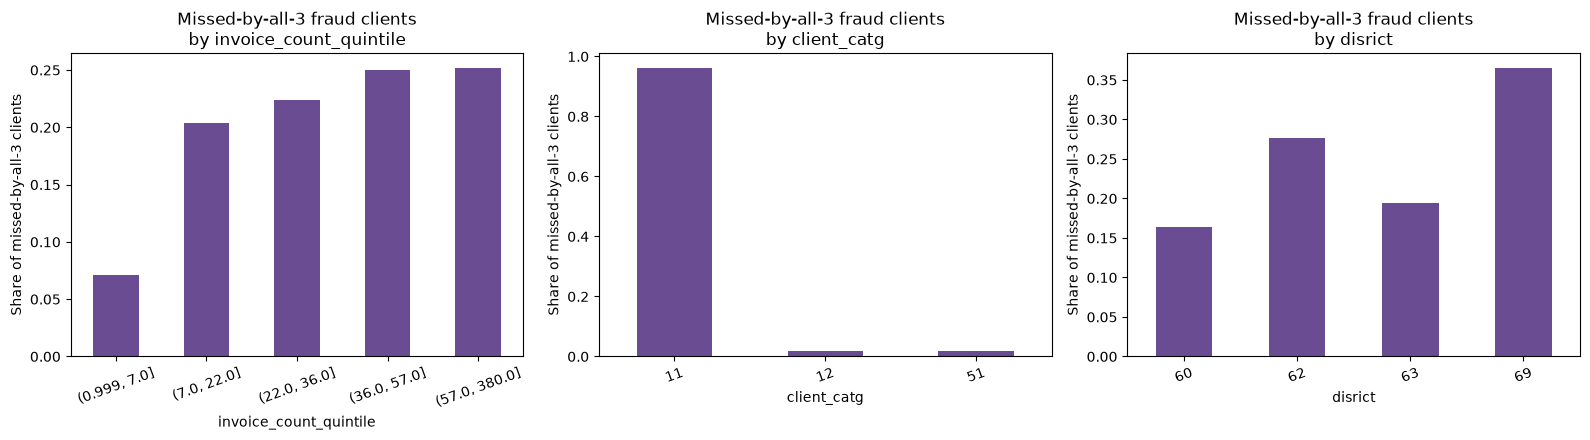

In [44]:
missed_by_all = analysis[analysis["agreement"] == "missed by all 3"]
print(f"{len(missed_by_all)} fraud clients missed by all 3 models -- where do they concentrate?")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, column in zip(axes, ["invoice_count_quintile", "client_catg", "disrict"]):
    missed_by_all[column].value_counts(normalize=True).sort_index().plot(
        kind="bar", ax=ax, color="#6A4C93"
    )
    ax.set(title=f"Missed-by-all-3 fraud clients\nby {column}", ylabel="Share of missed-by-all-3 clients")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## Step 8 — Feature importance comparison

Each model uses a different importance metric internally (LightGBM: split count, XGBoost: gain,
Random Forest: impurity decrease) -- these are **not comparable in magnitude across models**,
only within each model's own ranking. Shown side by side to see whether the three models are
relying on similar signals or genuinely different ones.

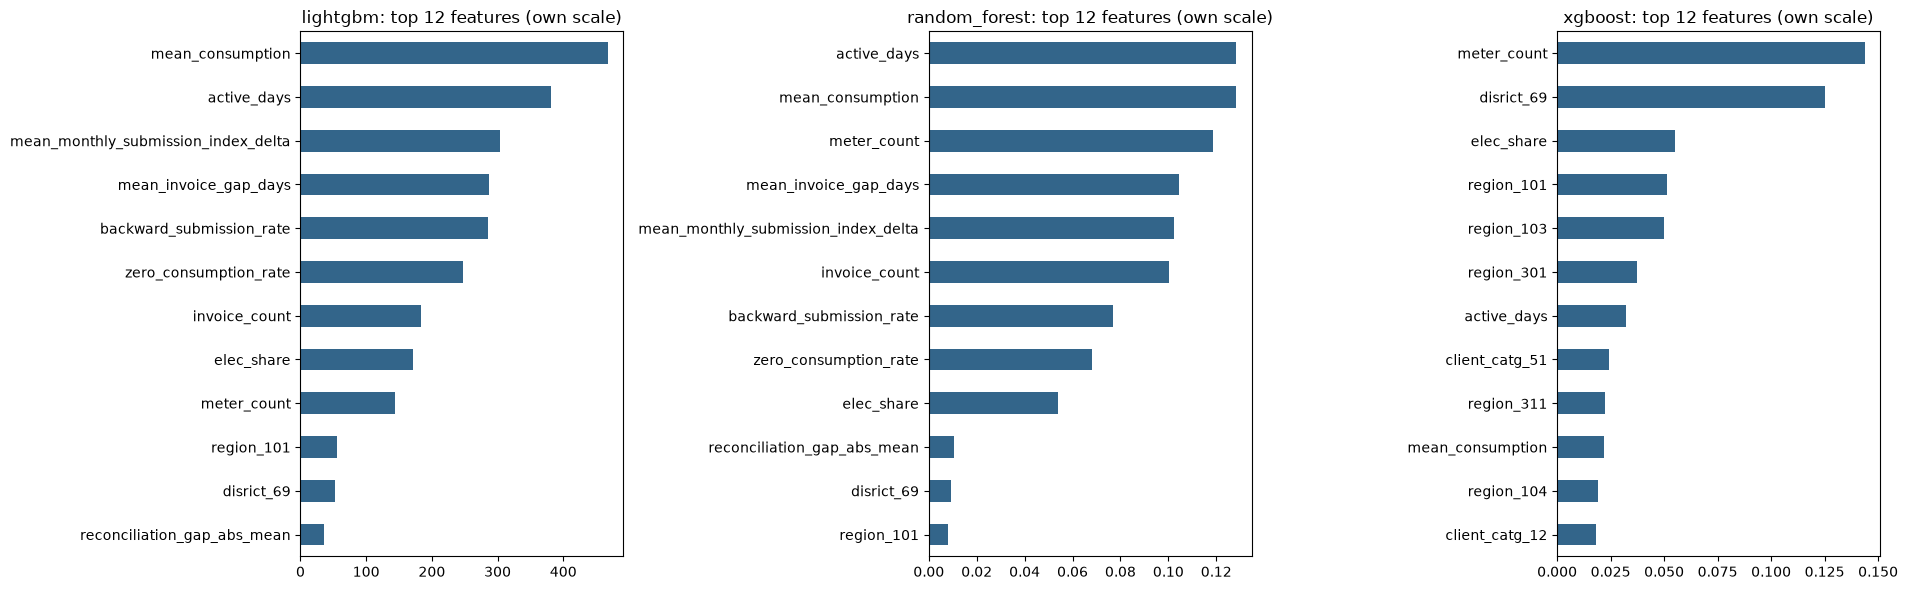

In [45]:
fitted_pipelines = {}
for name, model in model_specs.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipeline.fit(X, y)
    fitted_pipelines[name] = pipeline

feature_names = fitted_pipelines["lightgbm"].named_steps["preprocess"].get_feature_names_out()
feature_names = [name.split("__", 1)[-1] for name in feature_names]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for axis, name in zip(axes, model_names):
    importances = fitted_pipelines[name].named_steps["model"].feature_importances_
    top = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(12)
    top.iloc[::-1].plot(kind="barh", ax=axis, color="#33658A")
    axis.set(title=f"{name}: top 12 features (own scale)")
fig.tight_layout()
plt.show()

## Step 9 — A qualitative look at specific clients

A handful of fraud clients every model missed, and a handful every model caught -- not a
statistic, just a sanity-check read on what "hard" and "easy" actually look like here.

In [46]:
inspect_columns = [
    "client_id", "client_catg", "region", "disrict", "invoice_count", "active_days",
    "mean_consumption", "backwards_index_rate", "reconciliation_gap_abs_mean",
]

hardest_positions = missed_count[missed_count == len(model_names)].index
print(f"Fraud clients missed by all {len(model_names)} models: {len(hardest_positions)}")
display(analysis.iloc[hardest_positions][inspect_columns].head(8))

easiest_positions = missed_count[missed_count == 0].index
print(f"\nFraud clients caught by all {len(model_names)} models: {len(easiest_positions)}")
display(analysis.iloc[easiest_positions][inspect_columns].head(8))

Fraud clients missed by all 3 models: 2627


,client_id,client_catg,region,disrict,invoice_count,active_days,mean_consumption,backwards_index_rate,reconciliation_gap_abs_mean
31,train_Client_100032,11,308,63,18,2105,392.555556,0.0,0.0
80,train_Client_100091,11,101,60,43,3065,240.162791,0.0,0.0
97,train_Client_100109,11,312,63,23,2911,394.956522,0.0,0.0
188,train_Client_10022,11,107,69,37,4965,548.783784,0.0,0.0
202,train_Client_100235,11,302,62,9,1004,1292.333333,0.0,0.0
260,train_Client_10030,11,310,62,14,2187,1371.357143,0.0,0.0
281,train_Client_100322,11,104,69,19,3913,821.631579,0.0,0.0
317,train_Client_100362,11,371,62,105,4554,935.647619,0.0,0.0



Fraud clients caught by all 3 models: 1727


,client_id,client_catg,region,disrict,invoice_count,active_days,mean_consumption,backwards_index_rate,reconciliation_gap_abs_mean
152,train_Client_100177,11,306,63,62,5102,264.612903,0.0,0.000000
219,train_Client_100252,11,311,63,77,4819,263.909091,0.0,0.000000
240,train_Client_100277,11,104,69,29,5011,670.448276,0.0,0.000000
282,train_Client_100323,11,310,62,83,5101,244.771084,0.0,0.000000
329,train_Client_100376,11,103,69,36,4851,329.250000,0.0,0.000000
384,train_Client_100439,11,103,69,58,4128,415.137931,0.0,10.465517
421,train_Client_100481,11,311,63,56,4846,359.071429,0.0,0.000000
488,train_Client_10056,11,101,60,38,2195,154.552632,0.0,0.000000


## Results

> **Important:** the numerical segment, overlap, and feature-importance notes below were recorded before this notebook was aligned with the finalized 15-input contract. Rerun the cells above before presenting these detailed findings. The aggregate model comparison in `03_model_extension.ipynb` remains the current reference.

- **Confusion matrix @ top-10%**: LightGBM leads (precision 24.8%, recall 44.4%), Random Forest
  close behind (23.8% / 42.7%), XGBoost slightly further back (23.6% / 42.3%) -- consistent with
  `03_model_extension.ipynb`'s ranking.
- **`client_catg`**: all three models do noticeably *better* than their overall average on
  category 51 (the ~17%-fraud-rate segment) -- LightGBM 70.0% recall there vs. 44.4% overall --
  and noticeably *worse* on category 12 (recall 10.7-14.7%, but only 75 fraud cases, so read this
  cautiously rather than as a solid finding).
- **`disrict`**: district 63 is easier for every model (recall 55-58%) than the other three
  (35-43%), despite a mid-range fraud rate (6.5%) -- not the obvious "highest-fraud-rate" segment.
- **`region`**: real segment-robustness gap. Region 311 is easy for every model (recall
  62.6-68.0%), while regions 104 and 107 -- both with substantial fraud volume (569 and 524
  cases) -- are hard for every model (recall 24-33%). A strong overall number is hiding a
  meaningfully weaker region.
- **Invoice-count quintile -- the headline finding.** Recall for the shortest-history clients
  (1-7 invoices, 204 fraud cases) collapses to **2.0% (LightGBM), 2.9% (Random Forest), 3.4%
  (XGBoost)** -- essentially none of the fraud in this group is caught, by any model -- compared
  to 45-55% for the longest-history quintile. This is the observation-window bias the EDA flagged
  as a labeling risk, now confirmed as a real, severe *model* blind spot, not just a curiosity
  about the data.
- **Model agreement is high**: of 6,053 fraud clients, 1,746 (28.8%) are caught by all three
  models and 2,563 (42.4%) are missed by all three -- 71% of fraud clients get the *same* verdict
  from every model. Only 1,744 (28.8%) see any disagreement. False positives follow the same
  pattern: 89,089 non-fraud clients are correctly left alone by all three, and only ~13,252 are
  ever flagged by at least one.
- **Feature importance**: LightGBM and Random Forest substantially agree on what matters
  (`active_days`, `meter_count`, consumption and
  invoice-gap features dominate both top-12 lists). **XGBoost is notably different** -- its top
  features are dominated by one-hot geographic codes (`disrict_69`, `region_101`, `region_103`,
  `region_301`, `region_311`), a mechanism the other two barely use at all.

- **Step 7's scatter plots make the agreement finding visually concrete**: fraud clients form
  a clear diagonal band in every pairwise score comparison -- green ("caught by all 3") sits in
  the top-right (all scores high), purple ("missed by all 3") sits in the bottom-left (all
  scores low), and the orange/red disagreement cases fill the off-diagonal band where one model
  scores a client noticeably higher than another.
- **A nuance the segment charts surface that's easy to miss**: the *rate* of being missed is
  worst for short-history clients (the shortest quintile is ~93% purple), but the *absolute
  number* of always-missed fraud clients is actually concentrated more in the longer-history
  quintiles (24.7% of all "missed by all 3" clients come from the longest quintile vs. 7.5% from
  the shortest) -- simply because far more fraud cases exist there in total. Both are true at
  once: short-history clients are proportionally the model's biggest blind spot, but longer-
  history clients still account for more of the raw number of missed fraud cases. Worth stating
  both ways in the presentation rather than picking one.
- `client_catg`'s by-agreement chart is a good visual reminder of the sample-size caveat already
  noted: categories 12 and 51 are so small next to category 11 that their bars are barely
  visible in absolute terms -- read any category-12/51-specific finding as suggestive, not solid.

## Interpretation

- The high agreement between models (71% identical verdicts) explains why LightGBM, Random
  Forest, and XGBoost score similarly in aggregate: they're mostly finding the *same* fraud and
  missing the *same* fraud, not exploring genuinely different parts of the problem. The 2,563
  fraud clients missed by every model are the dataset's genuinely hard cases with the current
  features -- no amount of model-swapping alone is likely to catch them.
- The invoice-count collapse is the single most important finding here. A recall number like
  44% sounds usable for an inspection team, but that average is hiding a near-total blind spot
  for the newest, least-observed clients -- exactly the clients a real fraud program would most
  want early signal on. Reporting one aggregate recall number without this caveat would overstate
  the model's real-world usefulness.
- XGBoost's reliance on `disrict`/`region` one-hot codes is worth flagging as a fairness question,
  not just a technical curiosity: the EDA already cautioned that geographic fraud-rate patterns
  could partly reflect *where inspections have historically happened* rather than true fraud
  propensity (associations, not causes). XGBoost is structurally more exposed to that risk than
  LightGBM/Random Forest, which barely use geography at all -- a real consideration for model
  choice beyond raw PR-AUC.

### Next steps

- **Treat the invoice-count blind spot as the priority**, ahead of hyperparameter tuning: tuning
  a model's settings won't fix a missing-signal problem for short-history clients. Worth trying
  relative/normalized feature versions (e.g., consumption or gap features expressed per-invoice
  or per-active-day rather than as raw sums) that don't structurally require a long history to
  be informative, and stating the limitation explicitly in the presentation regardless.
- **Look closer at regions 104 and 107** before finalizing -- substantial fraud volume, poor
  recall across every model, worth understanding whether that's a genuine harder fraud pattern or
  a data/feature gap specific to those regions.
- **Try a soft (probability-averaging) ensemble of LightGBM + Random Forest** -- they share most
  of their top features and agree most often, so an ensemble is more about smoothing noise than
  combining genuinely different signals; test it against each individual model via the same CV
  scheme before adopting it. An "OR"-style union is not recommended: it would recover some of the
  1,744 disagreement cases but roughly triples the false-positive count (13,252 vs. ~8,000-8,500
  per model alone).
- **Now proceed to hyperparameter tuning of LightGBM** (the confirmed single leader from `03`),
  informed by the above -- and re-check the invoice-count quintile breakdown afterward to confirm
  tuning didn't just improve the easy majority while leaving the short-history blind spot as bad
  as before.
- **`client_catg == 12`'s weak recall** is a low-confidence finding (75 fraud cases) -- flag it,
  don't act on it without more data.